In [61]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import math
import pandas as pd
import bisect
import uuid
from enum import Enum
import requests
from pathlib import Path
import os

from fame import *

In [62]:
# Gemini-generated

# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [63]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [64]:
# Behind the scenes, this pulls from Celestrak if we do not specify tle_file

satellites = [
    # Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt)),
    # Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt", tle_file=tle_file_name_txt)),
    # Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt)),
    # Satellite("PELICAN-6 ", Orbital("PELICAN 6", tle_file=tle_file_name_txt)),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [65]:

#tle_file_name_txt = "tles/all_tles_20260121.txt"

In [66]:
flock_names = []

with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("FLOCK"):
            # .strip() removes the trailing newline character (\n)
            flock_names.append(line.strip()) 
            


In [67]:
len(flock_names)

124

In [68]:
# planet_satellites = []
# 14-19 decayed

dove_satellites = [
    Satellite(dove_name, Orbital(dove_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)
    for dove_name in flock_names
    ]

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt)),
]
# pelican_satellites = [
#     #Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt)),
#     #Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt)),
#     Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt)),
#     Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt)),
#     Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt)),
#     Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt)),

# ]
# tanager_satellites = [
#     Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt)),

# ]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt)),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt)),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt)),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt)),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt)),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]

loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt))]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt))]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt)),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt)),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt)),   
]

In [69]:
#all_satellites = dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites
all_satellites = dove_satellites+skysat_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites
print(f"Checking {len(all_satellites)} satellites for deep space or bad data anomalies...")
sanitized_satellites = []

for sat in all_satellites:
    try:
        # Test if pyorbital can actually step across your window boundaries
        _ = sat.orbit.get_lonlatalt(min_time)
        _ = sat.orbit.get_lonlatalt(max_time)
        sanitized_satellites.append(sat)
    except (NotImplementedError, Exception):
        # Quietly discard deep space, decayed, or missing TLE matches
        print(f"   [Skipped] {sat.name} failed orbit propagation tests.")

all_satellites = sanitized_satellites
print(f"✅ Cleared {len(all_satellites)} LEO-compliant satellites for execution.")
# ---------------------------------------------------------------------

Checking 152 satellites for deep space or bad data anomalies...
   [Skipped] FLOCK 4Q 1 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 16 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 11 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 36 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 12 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 28 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 27 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 26 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 31 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 30 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 25 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 29 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 22 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 23 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 33 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 35 failed orbit propagation tests.
   [Skipped] FLOCK 4Q 34 

In [70]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "DOVE" in sat_name:
        return "midnightblue"
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [71]:
satcolor

{}

In [72]:

ground_stations = [
    # Location(
    #     -79.55,
    #     8.9833,
    #     0.028,
    #     "KSAT Panama",
    # ),
    # Location(
    #     -51.73363,
    #     64.182789,
    #     0,
    #     "KSAT Nuuk",
    # ),
    # Location(
    #     2.53219,
    #     -72.01243,
    #     0,
    #     "KSAT Troll",
    # ),
    # Location(
    #     142.3689,
    #     43.8,
    #     0,
    #     "KSAT Hokkaido",
    # ),
    # Location(
    #     103.9915,
    #     1.3661,
    #     0,
    #     "KSAT Singapore",
    # ),
    # Location(
    #     -70.85021,
    #     -52.93279,
    #     0,
    #     "KSAT Punta Arenas",
    # ),
    # Location(
    #     127.7766,
    #     26.4055,
    #     0,
    #     "KSAT Okinawa",
    # ),
    # Location(
    #     57.5565,
    #     -20.1142,
    #     0,
    #     "KSAT Mauritius",
    # ),
    # Location(
    #     22.62216,
    #     37.84604,
    #     0,
    #     "KSAT Nemea",
    # ),
    # Location(
    #     31.12509,
    #     70.36779,
    #     0,
    #     "KSAT Vardo",
    # ),
    # Location(
    #     15.39964,
    #     78.22875,
    #     0,
    #     "KSAT Svalbard",
    # ),
    Location(
        3.8,
        52,
        0,
        "Rotterdam-ish",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

C:\Users\davidf\AppData\Local\Temp\ipykernel_35060\186248224.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axglobal.legend()
C:\Users\davidf\AppData\Local\Temp\ipykernel_35060\186248224.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axglobal.legend()
C:\Users\davidf\AppData\Local\Temp\ipykernel_35060\186248224.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axglobal.legend()
C:\Users\davidf\AppData\Local\Temp\ipykernel_35060\186248224.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with n

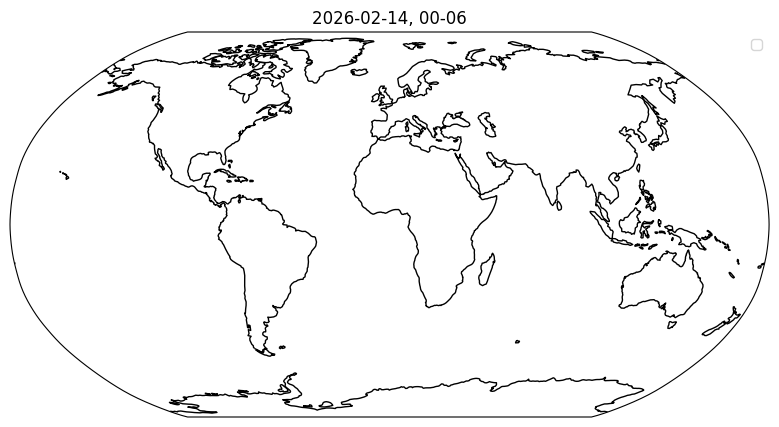

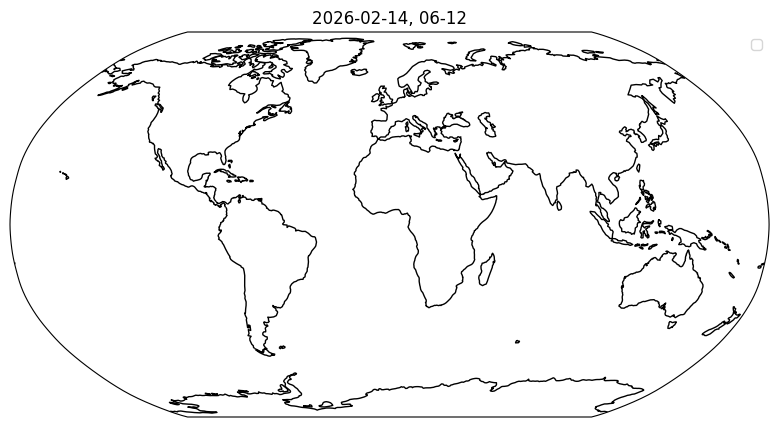

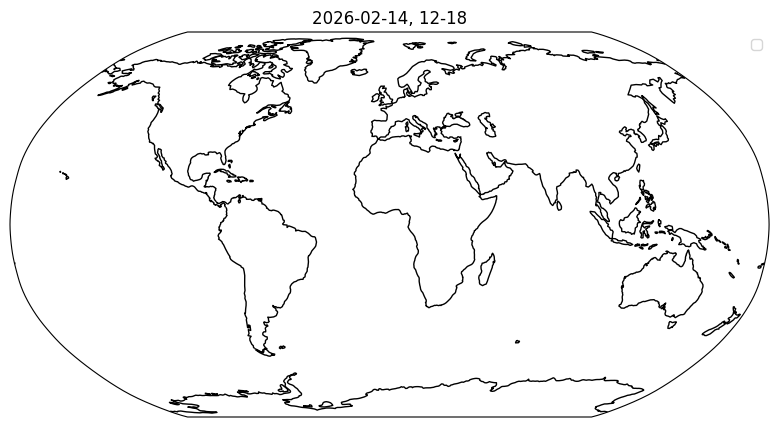

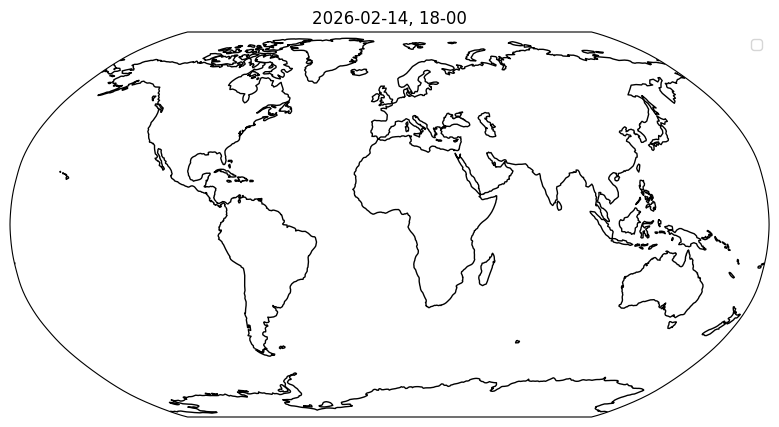

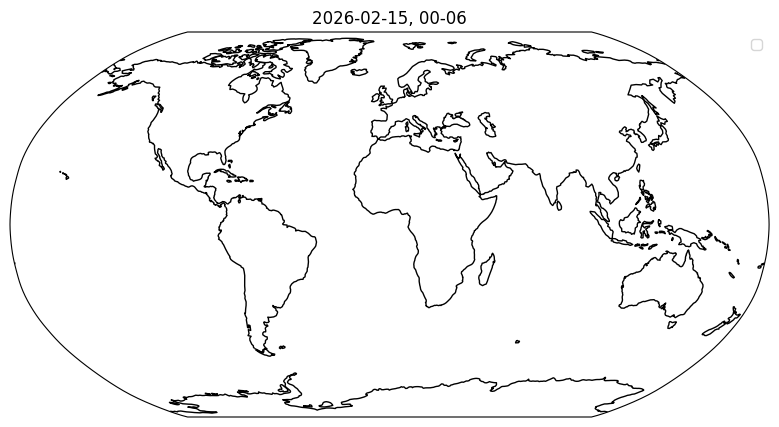

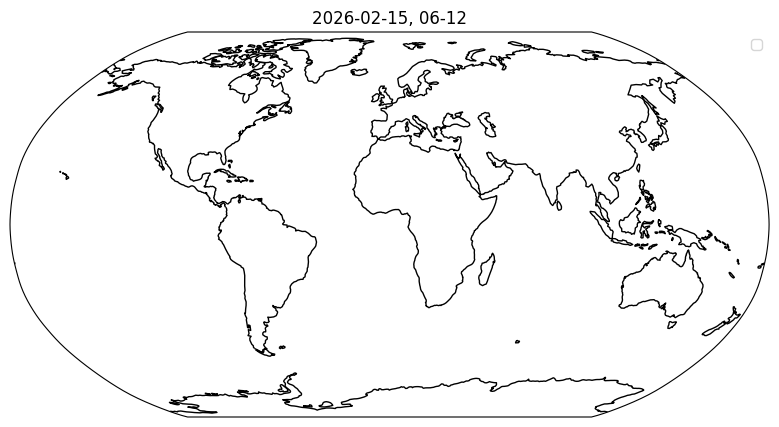

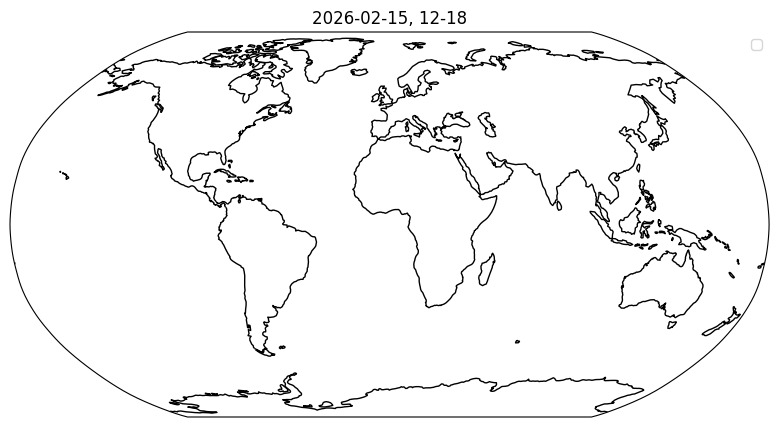

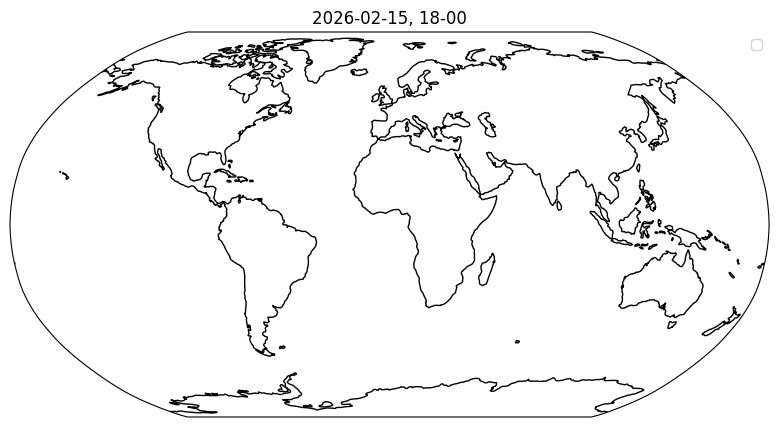

In [73]:
duration_h = 6

for start_day in range(14,16):
    for start_hour in range(0,24,duration_h):
        min_time = dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0)
        duration = dt.timedelta(seconds=3600*duration_h)
        comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
            ground_stations=ground_stations,
            satellites=all_satellites,
            min_time=min_time,
            max_time=min_time+duration,
            passes_error_s=60,
            passes_horizon_deg=45
        )

        stride_s = 60
        plot_range_s = 10800

        # comm_opportunities_by_sat

        figglobal = plt.figure(figsize=(10,5))
        axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
        # axglobal.set_global()
        axglobal.coastlines()

        # fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

        ground_station_dict = {gs.name: gs for gs in ground_stations}

        for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
            for (ground_station, satpass) in sat_passes_with_gs:
                # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
                # ax.coastlines()
            
                # request location
                # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
                # ground_station = ground_station_dict[gs]
                axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            
                # Where is the satellite?
            
                _dt = dt.timedelta(seconds=stride_s)
                time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]
            
                _orbit = satellite.orbit
                _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
                # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
                axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])
                
                axglobal.plot(_llas[0][0],_llas[0][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
                axglobal.plot(_llas[-1][0],_llas[-1][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

                axglobal.text(_llas[0][0],_llas[0][1], "{}".format(satpass.rise.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())
                axglobal.text(_llas[-1][0],_llas[-1][1], "{}".format(satpass.fall.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())

                # Where is the satellite looking?
                # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
                # axglobal.plot(
                #     [float(orequest.lon_deg), _highest_lla[0]],
                #     [float(orequest.lat_deg), _highest_lla[1]],
                #     ':k',
                #     transform=ccrs.Geodetic()
                # )
                
                # ax.plot(
                #     [float(orequest.lon_deg), _highest_lla[0]],
                #     [float(orequest.lat_deg), _highest_lla[1]],
                #     ':k',
                #     transform=ccrs.Geodetic()
                # )
                
                # request_counter += 1
        axglobal.legend()
        axglobal.set_title("{}-{}".format(min_time.strftime("%Y-%m-%d, %H"), (min_time+duration).strftime("%H")))
        plt.savefig("{}-{}-{}h.png".format(min_time.strftime("%Y-%m-%d %H"),(min_time+duration).strftime("%H"), duration_h), bbox_inches='tight')

In [74]:
PLOT_TIMELAPSE = False

if PLOT_TIMELAPSE:

        # duration_h = 6

        # for start_day in range(14,16):
        #     for start_hour in range(0,24,duration_h):

        _plot_offset_deg = 8


        start_time = dt.datetime(2026, 2, 14, 0, 0, 0, 0)
        end_time = dt.datetime(2026, 2, 16, 0, 0, 0, 0)

        start_cut_time = start_time #dt.datetime(2026, 2, 15, 20, 1, 0, 0)

        tl_duration = end_time-start_time
        tl_timestep_s = 20

        streak_duration = dt.timedelta(seconds=180)
        streak_stride_s = 2

        # comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
        #     ground_stations=ground_stations,
        #     satellites=all_satellites,
        #     min_time=min_time,
        #     max_time=min_time+duration,
        #     passes_error_s=60,
        #     passes_horizon_deg=45
        # )


        # plot_range_s = 120

        # comm_opportunities_by_sat
        for frame_index in range(int(np.ceil(tl_duration.total_seconds()/tl_timestep_s))):

                time_offset = dt.timedelta(seconds=tl_timestep_s*frame_index)

                curr_time = start_time + time_offset

                if curr_time<start_cut_time:
                        continue

                figglobal = plt.figure(figsize=(10,5))
                axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
                # axglobal.set_global()
                axglobal.coastlines()

                # fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

                ground_station_dict = {gs.name: gs for gs in ground_stations}

                # for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
                #     for (ground_station, satpass) in sat_passes_with_gs:
                for satellite in all_satellites:
                        # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
                        # ax.coastlines()

                        # request location
                        # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
                        # ground_station = ground_station_dict[gs]

                        axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )

                        axes_extents = (float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg)


                        # Where is the satellite?

                        _dt = dt.timedelta(seconds=streak_stride_s)
                        # time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

                        time_steps_for_plotting = [curr_time-streak_duration + _dt*i for i in range(int(math.ceil(streak_duration.total_seconds()/_dt.total_seconds())))]

                        _orbit = satellite.orbit
                        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]

                        current_sat_lla = _llas[-1]
                        # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
                        for lla_ix in range(len(time_steps_for_plotting)-1):
                                # axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])
                                axglobal.plot([_llas[lla_ix+1][0], _llas[lla_ix][0]], [_llas[lla_ix+1][1], _llas[lla_ix][1]], transform=ccrs.Geodetic(), color=satcolor[satellite.name], alpha = (lla_ix+1)/len(_llas))

                        # axglobal.plot(_llas[0][0],_llas[0][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
                        axglobal.plot(current_sat_lla[0],current_sat_lla[1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

                        if (current_sat_lla[0]>axes_extents[0] and current_sat_lla[0]<axes_extents[1] and current_sat_lla[1]>axes_extents[2] and current_sat_lla[1]<axes_extents[3]):
                                axglobal.text(_llas[-1][0],_llas[-1][1], "{}".format(satellite.name), transform=ccrs.Geodetic(), clip_on=True)


                        # axglobal.text(_llas[0][0],_llas[0][1], "{}".format(satpass.rise.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())

                        # axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg))


                        # Where is the satellite looking?
                        # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
                        # axglobal.plot(
                        #     [float(orequest.lon_deg), _highest_lla[0]],
                        #     [float(orequest.lat_deg), _highest_lla[1]],
                        #     ':k',
                        #     transform=ccrs.Geodetic()
                        # )

                        # ax.plot(
                        #     [float(orequest.lon_deg), _highest_lla[0]],
                        #     [float(orequest.lat_deg), _highest_lla[1]],
                        #     ':k',
                        #     transform=ccrs.Geodetic()
                        # )

                        # request_counter += 1
                # axglobal.legend()
                axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())
                axglobal.set_title("{}".format(curr_time.strftime("%Y-%m-%d, %H:%M:%S")))
                plt.savefig("timelapse/Rotterdam_tl_FRAME{:05d}.png".format(frame_index), bbox_inches='tight')

TODO:
- [ ] Make the above into a movie.
  - [ ] At time t, plot the satellites overhead with a modest trail (fading?)
  - [ ] Plot for a bunch of ts.
- [ ] Show the view from the ground
  - [ ] All-sky circular view
  - [ ] Get az, alt of the satellites as seen from the ground
  - [ ] Plot with a modest trail and a moving label
                                                                     

In [75]:
min_time = dt.datetime(2026, 2, 14, 0, 0, 0, 0)

duration = dt.timedelta(seconds=3600*6)

In [76]:
comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
    ground_stations=ground_stations,
    satellites=all_satellites,
    min_time=min_time,
    max_time=min_time+duration,
    passes_error_s=60,
    passes_horizon_deg=45
)

In [77]:
comm_opportunities_by_sat_and_station

{}

In [78]:
stride_s = 60
plot_range_s = 10800

C:\Users\davidf\AppData\Local\Temp\ipykernel_35060\3015967824.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axglobal.legend()


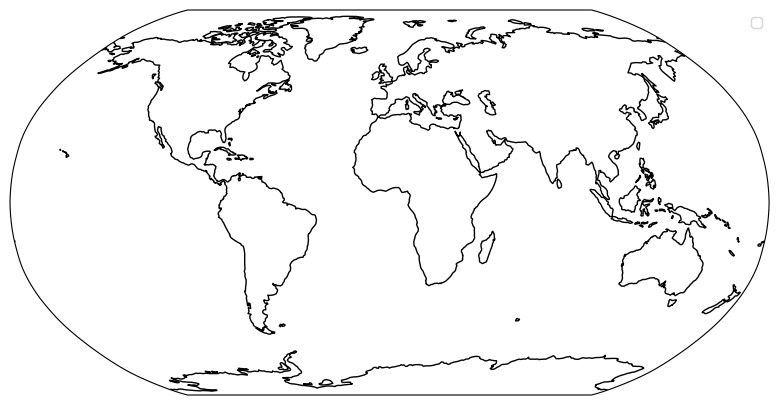

In [79]:
# comm_opportunities_by_sat

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

# fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

ground_station_dict = {gs.name: gs for gs in ground_stations}

for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
    for (ground_station, satpass) in sat_passes_with_gs:
        # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
        # ax.coastlines()
    
        # request location
        # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
        # ground_station = ground_station_dict[gs]
        axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    
        # Where is the satellite?
    
        _dt = dt.timedelta(seconds=stride_s)
        time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]
    
        _orbit = satellite.orbit
        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
        # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
        axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name)
    
        # Where is the satellite looking?
        # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
        # axglobal.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # ax.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # request_counter += 1
axglobal.legend()

In [80]:
comm_opportunities_by_sat

{}

In [81]:
# The first thing you do with a new batch of satellites: plot ground tracks. The simple way.



time_steps_for_plotting = [dt.datetime.now(dt.timezone.utc).replace(tzinfo=None) + dt.timedelta(seconds=stride_s*i) for i in range(int(plot_range_s/stride_s))]

llas = {}
for satellite in all_satellites:
    llas[satellite] = [satellite.orbit.get_lonlatalt(t) for t in time_steps_for_plotting]


C:\Users\davidf\AppData\Local\Temp\ipykernel_35060\2482872964.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


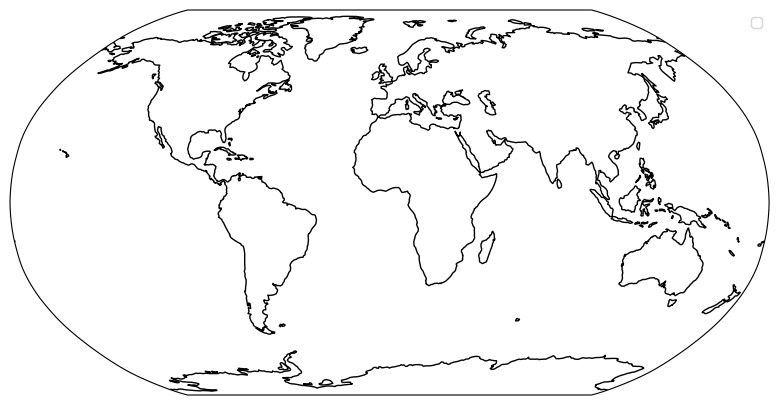

In [82]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for satellite in llas:
    ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite.name)
ax.legend()

In [83]:
jpl_lla = [-118.1730155, 34.2009478, 0.329]
passes_horizon_h = 12
passes_error_s = 60
passes_horizon_deg = 0.

passes = {}

for satellite in all_satellites:
    passes[satellite] = satellite.orbit.get_next_passes(dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),passes_horizon_h,jpl_lla[0],jpl_lla[1],jpl_lla[2],passes_error_s,passes_horizon_deg)

In [84]:
for satellite, passlist in passes.items():
    if len(passlist):
        print("{} passes for {}".format(len(passlist), satellite.name))
        for satpass in passlist:
            print("Start: {}. End: {}. Max altitude: {}".format(satpass[0], satpass[1], satpass[2]))
    else:
        print("No passes for {}".format(satellite.name))

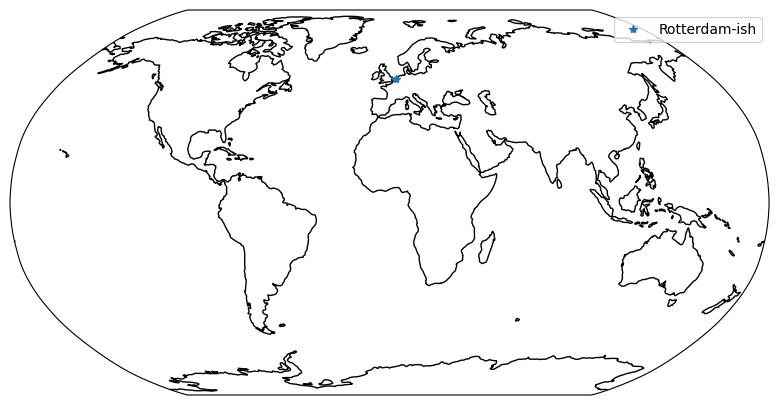

In [85]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for station in ground_stations:
    ax.plot(station.lon_deg, station.lat_deg,'*',transform=ccrs.Geodetic(), label=station.name)
ax.legend()

In [86]:
print(get_elevation_usgs(-118,34))
print(get_elevation_from_open_elevation(-118,34))

295.500427246
307.0


In [87]:
# min_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
# max_time = min_time + dt.timedelta(hours=24)

min_time = dt.datetime(2026, 2, 14, 0, 0, 0, 0)

duration = dt.timedelta(seconds=3600*6)
max_time = min_time+duration

os = ObservationRequest(-118,34, alt_km=0.307, min_time=min_time, max_time=max_time)

In [88]:
obs_requests = [
    ObservationRequest(3.8, 52, min_time=min_time, max_time=max_time, alt_km=0.307, request_name="Rotterdam-ish", min_elevation_deg=45),
    # ObservationRequest(
        # 3.8,
        # 52,
        # 0,
        # "Rotterdam-ish",
    # ),
    # ObservationRequest(8., 45., min_time=min_time, max_time=max_time, alt_km=0.216),
    # ObservationRequest(-80., 34., min_time=min_time, max_time=max_time, alt_km=0.041),
]

In [89]:
observation_opportunities = find_observation_opportunities(obs_requests, all_satellites)

In [90]:
# for request, passes in observation_opportunities.items():
#     for satellite, satpasses in passes.items():
#         for satpass in satpasses:
#             print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))

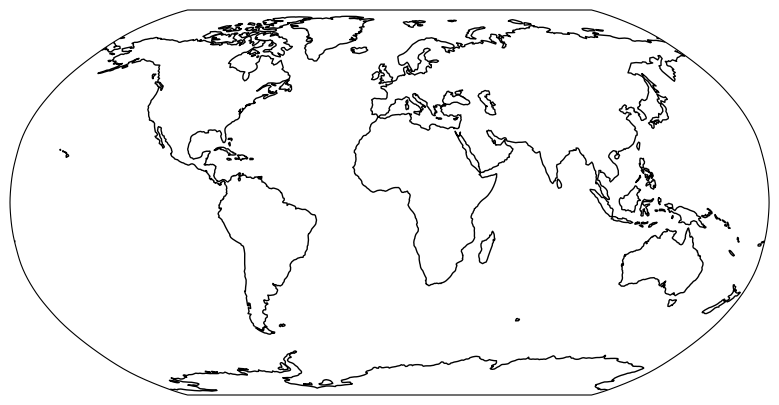

<Figure size 300x0 with 0 Axes>

In [91]:
_plot_offset_deg = 20

request_counter = 1
pass_counter = 0

request_number = len(observation_opportunities)
max_num_passes = max([sum([len(passes) for passes in all_passes.values()]) for all_passes in observation_opportunities.values()])

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3*max_num_passes))

for orequest, all_passes in observation_opportunities.items():
    pass_counter = 0
    for satellite, passes in all_passes.items():
        for satpass in passes:
            ax = fig.add_subplot(max_num_passes, request_number, request_counter + request_number*pass_counter, projection=ccrs.Robinson())
            pass_counter += 1
            # ax.set_global()
            # ax.set_extent((float(orequest.lon_deg)-_plot_offset_deg, float(orequest.lon_deg)+_plot_offset_deg, float(orequest.lat_deg)-_plot_offset_deg, float(orequest.lat_deg)+_plot_offset_deg))
            ax.coastlines()
        
            # request location
            ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

            # Where is the satellite?

            _dt = dt.timedelta(seconds=stride_s)
            time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

            # for satellite, orbit in satellites.items():
            _orbit = satellite.orbit
            _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
            ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
            axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

## Pick the best request. Greeedy, no conflicts or anything

In [92]:
best_request = {r: None for r in obs_requests}

for request, passes in observation_opportunities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request[request] = (_best_satellite, _best_pass)

In [93]:
best_request

{Request Rotterdam-ish: (None, None)}

AttributeError: 'NoneType' object has no attribute 'fall'

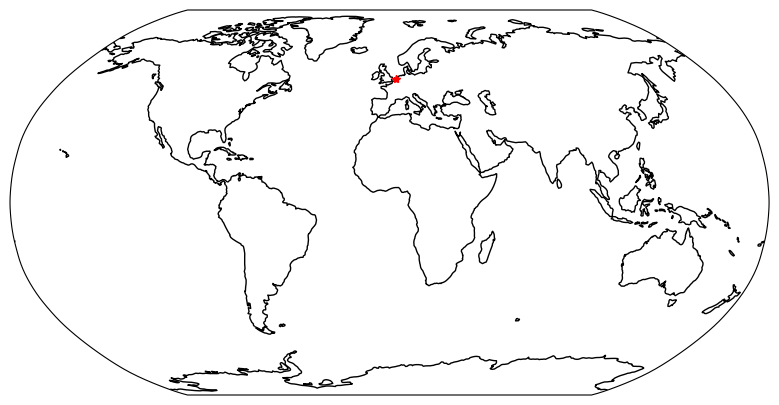

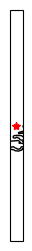

In [94]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3))

for orequest, (satellite, satpass) in best_request.items():
    ax = fig.add_subplot(1, request_number, request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    # for satellite, orbit in satellites.items():
    _orbit = satellite.orbit
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

# More locations

Read a DB of world cities. Generate a good number of locations.

In [ ]:
cities_of_the_world = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

In [ ]:
sampled_world_cities = cities_of_the_world.sample(n=100,weights='population',axis=0, random_state=0)

In [ ]:
one_hundred_sampled_cities = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities.iterrows()
]

In [ ]:
observation_opportunities_cities = find_observation_opportunities(one_hundred_sampled_cities, satellites)

In [ ]:
best_request_cities = {r: None for r in one_hundred_sampled_cities}

for request, passes in observation_opportunities_cities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request_cities[request] = (_best_satellite, _best_pass)

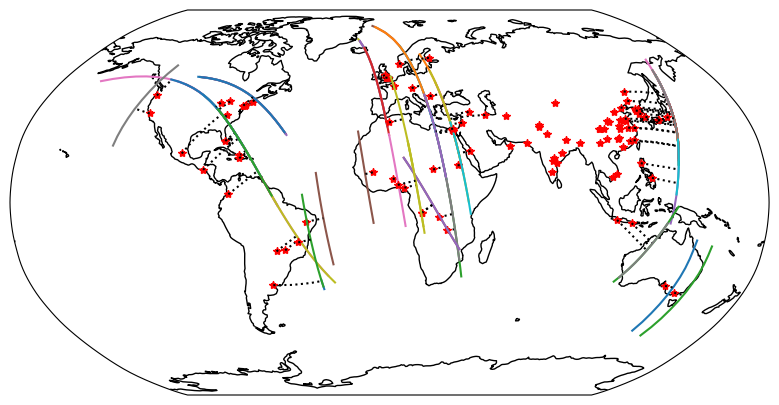

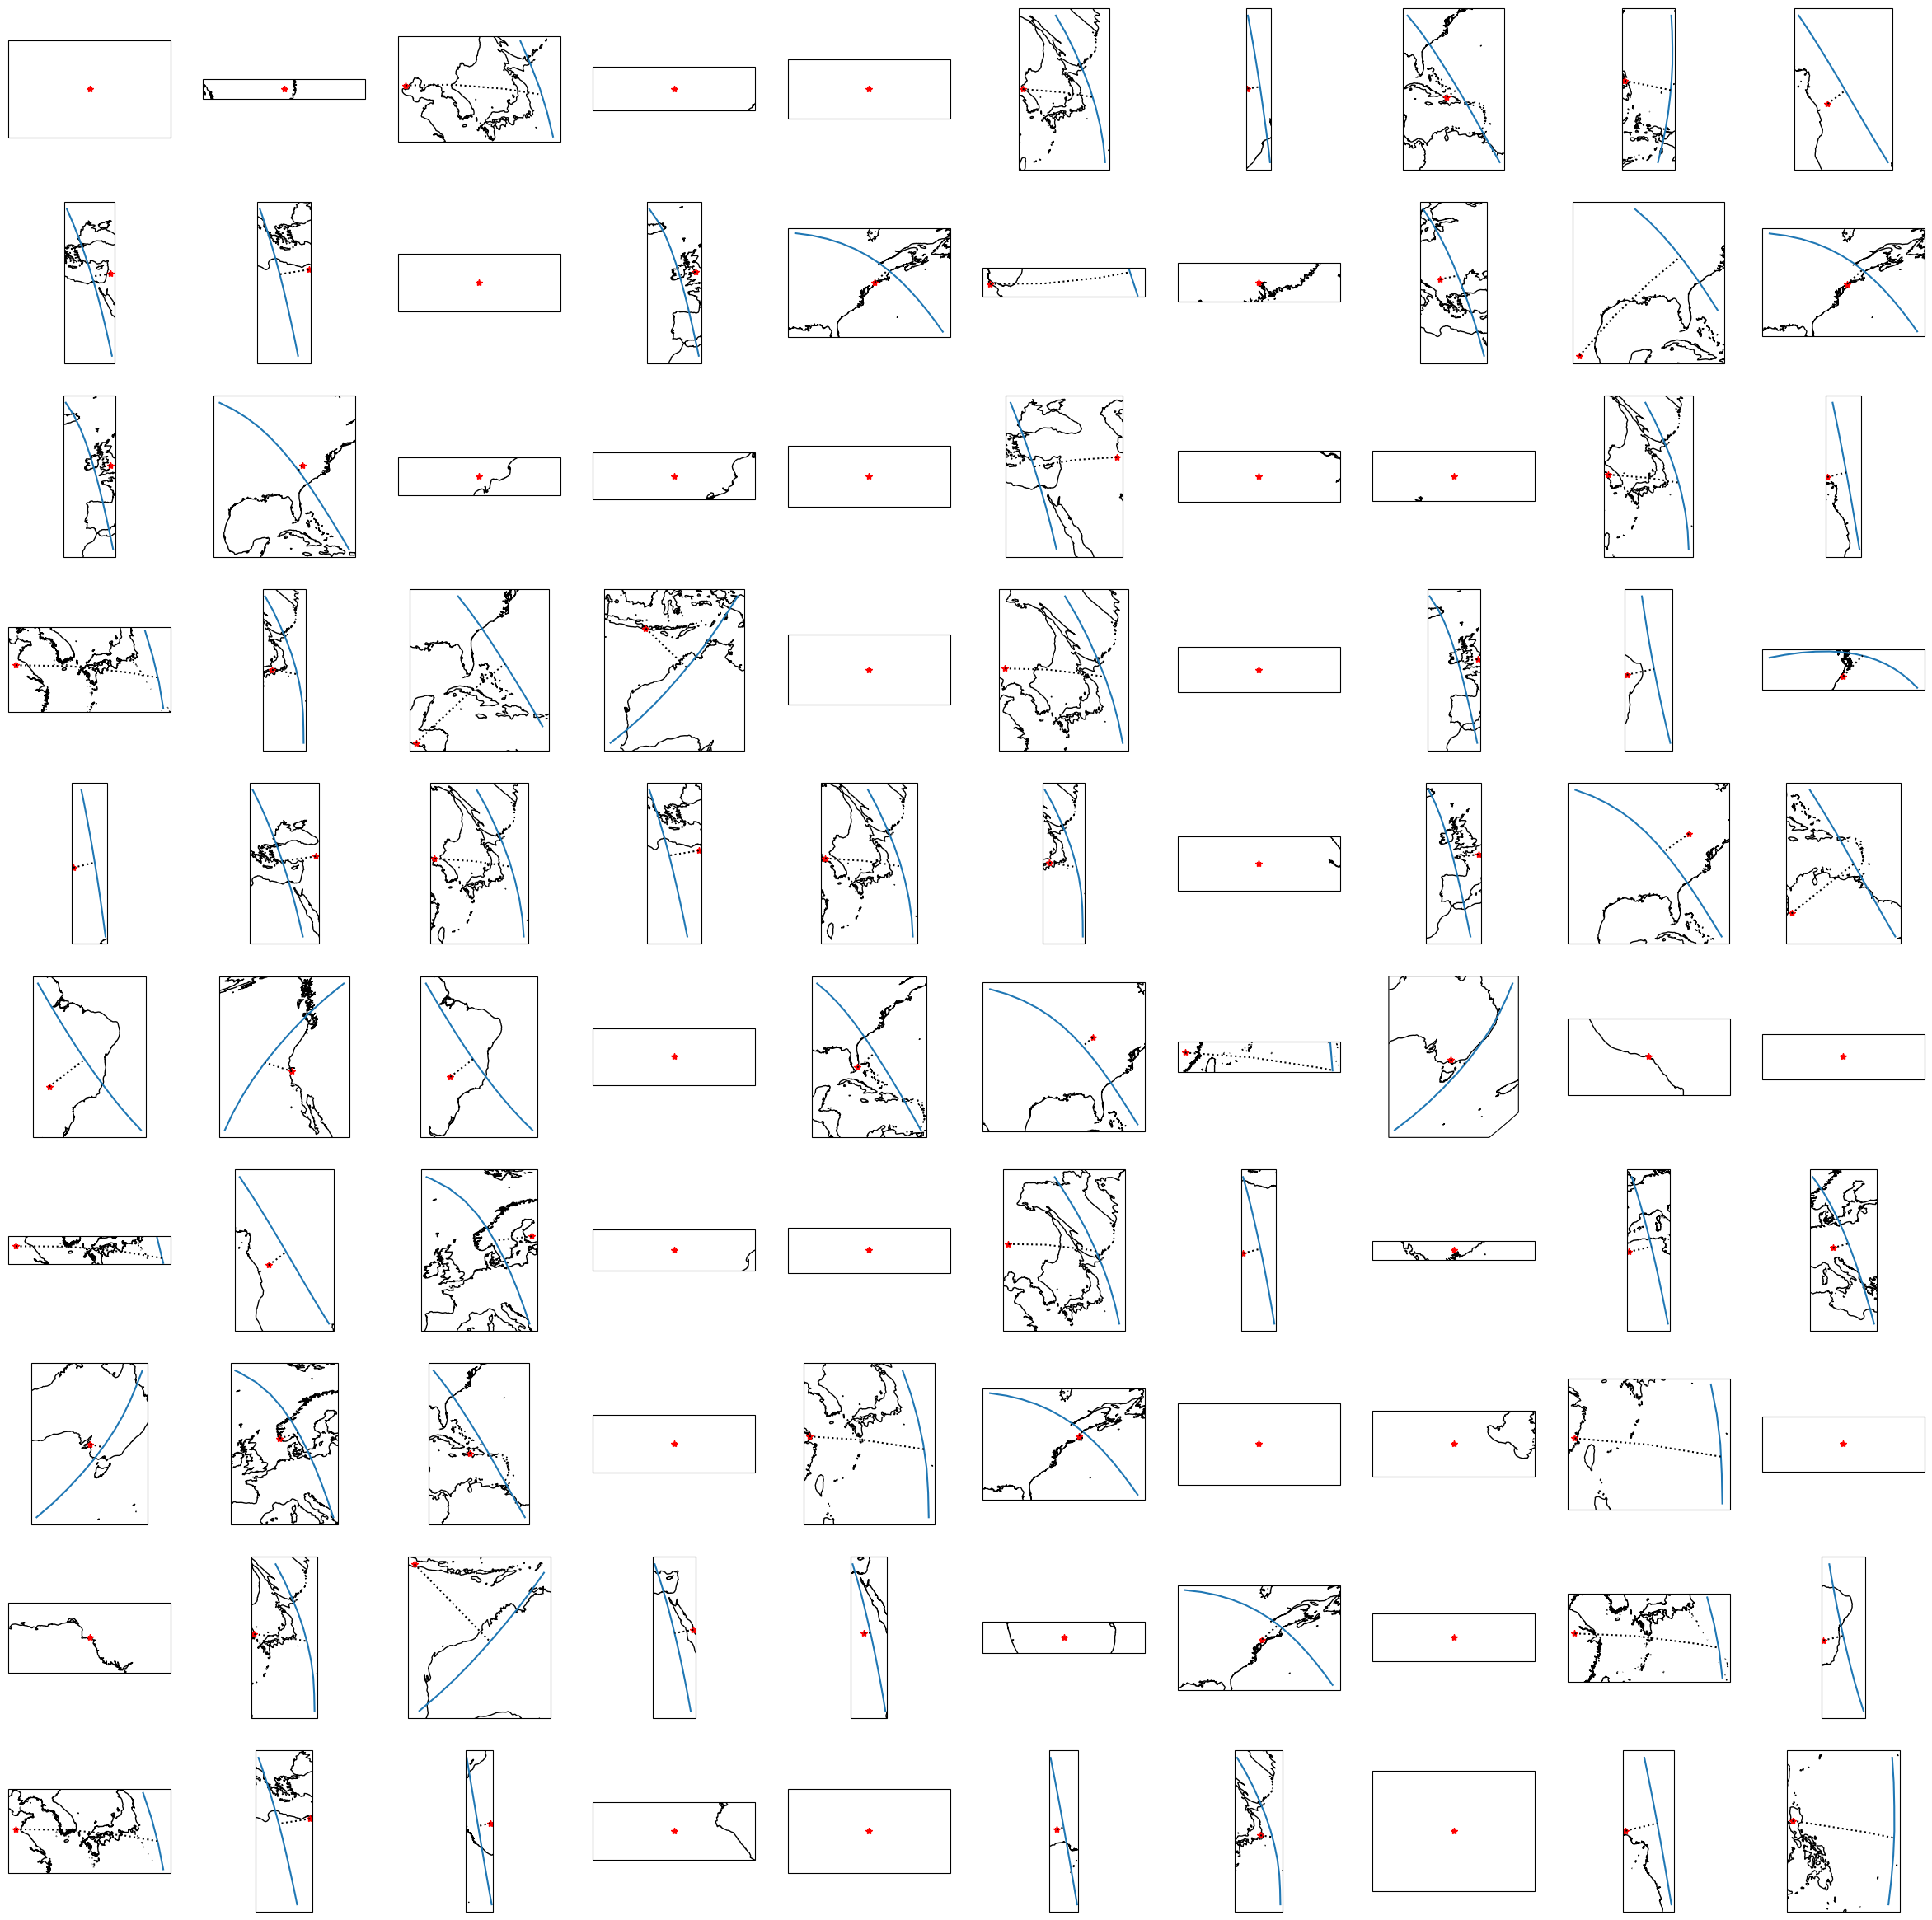

In [ ]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities_cities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

for orequest, (satellite, satpass) in best_request_cities.items():
    ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    if satpass is not None:
        time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

        _orbit = satellite.orbit
        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
        ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
        axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

        # Where is the satellite looking?
        _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
        axglobal.plot(
            [float(orequest.lon_deg), _highest_lla[0]],
            [float(orequest.lat_deg), _highest_lla[1]],
            ':k',
            transform=ccrs.Geodetic()
        )
        ax.plot(
            [float(orequest.lon_deg), _highest_lla[0]],
            [float(orequest.lat_deg), _highest_lla[1]],
            ':k',
            transform=ccrs.Geodetic()
        )
    
    request_counter += 1